## Importação das bibliotecas

In [2]:

import os
import numpy as np
import rasterio
from rasterio.mask import mask
import openeo
import json
import time
from datetime import datetime, timedelta
import requests
import subprocess
import os
import json
import openeo
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import sys
import rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask
import geopandas as gpd
import xarray
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rio

## Conexão com o serviço OpenEO

In [ ]:
# Conectando ao serviço OpenEO
# Aqui, precisei fazer login no site. Isso me permitiu autenticar
connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc_device(store_refresh_token=True)

# Aqui consigo verificar as informações da conexão (deve me retornar os meus dados de conta)
# connection.describe_account()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=QCZU-VHYS 📋 to authenticate.

✅ Authorized successfully

<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## Definição da região e período de estudo 

In [4]:
# Aqui, você deve escrever o ano, mês e dia em que ocorreu o deslizamento de terra
ANO = 2022
MES = 2
DIA = 15
prod_dir = './sentinel2_10m'

In [5]:
# Crie um arquivo geojson da região de interesse através do QGIS e EXPORTE EM EPSG 4326
# Carregando o arquivo GeoJSON
geojson_path = "./study_area/contorno_area_estudo.geojson"
with open(geojson_path) as f:
    geojson = json.load(f)
    
geom = geojson['features'][0]['geometry']

In [6]:
# Definindo a data do deslizamento
landslide_date = datetime.strptime(f"{ANO}-{MES}-{DIA}", "%Y-%m-%d")
landslide_date_str = landslide_date.strftime("%Y-%m-%d")

In [7]:
# O intervalo temporal abaixo permitirá extrair imagens no período anterior e posterior ao deslizamento
before_start_date = (landslide_date - timedelta(days=30)).strftime("%Y-%m-%d") # 30 dia antes 
after_end_date   = (landslide_date + timedelta(days=30)).strftime("%Y-%m-%d")    # 30 dias depois

In [8]:
# Diretório de saída para os arquivos TIFF
output_dir_NDVI = f"{prod_dir}/MSAVI2/"
output_dir_RGB = f"{prod_dir}/RGB/"

## Carregamento da coleção de imagens do período anterior e posterior ao deslizamento de terra

In [9]:
# Para saber o nome das bandas a extrair
satelite = 'SENTINEL2_L2A' # Diga aqui o satélite de interesse
collection_details = connection.describe_collection(satelite)

# Lista as bandas disponíveis
bands = [band['name'] for band in collection_details['summaries']['eo:bands']]
print(f"Bandas disponíveis na coleção {satelite}:")
print(bands)

Bandas disponíveis na coleção SENTINEL2_L2A:
['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'WVP', 'AOT', 'SCL', 'sunAzimuthAngles', 'sunZenithAngles', 'viewAzimuthMean', 'viewZenithMean']


Observação: Por que chamamos de datacube?  
 
Os dados são representados como cubos de dados no openEO, que são matrizes multidimensionais com informações adicionais sobre sua dimensionalidade. Os cubos de dados podem fornecer uma interface agradável e organizada para dados espaço-temporais. Assim, temos quatro dimensões:  
x, y, as bandas e o tempo:    

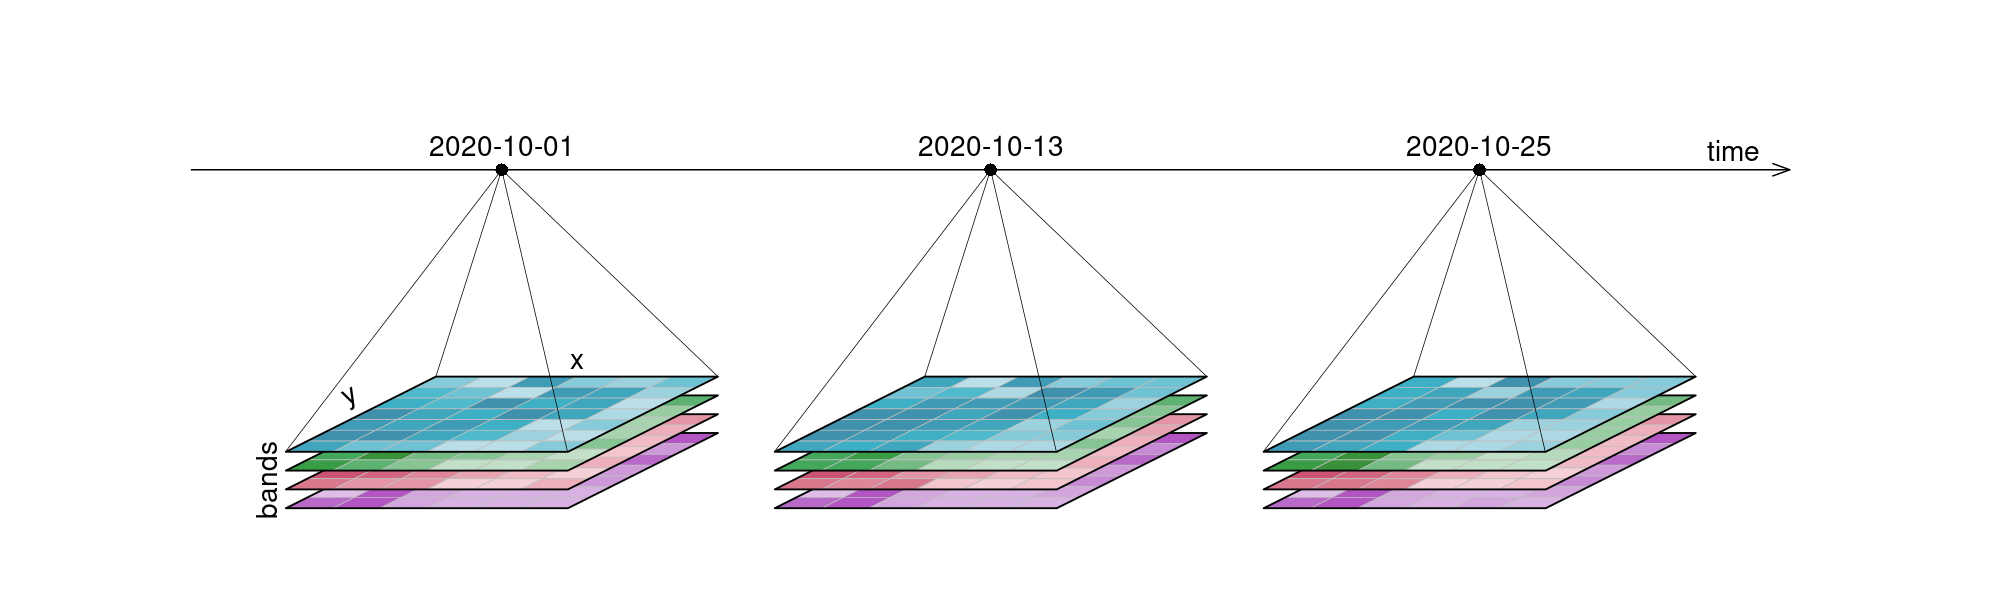

In [10]:
# Carrego a coleção para o período anterior ao deslizamento
datacube_before = connection.load_collection(
    "SENTINEL2_L2A", # selecionamos a coleção do sentinel2 L2A, porque são produtos de reflectãncia de superfície, com correção atmosférica. 
                     # A opção COPERNICUS/S2 (L1C): São produtos de reflectância no topo da atmosfera (TOA) sem correção atmosférica.
    spatial_extent=geom,
    temporal_extent=[before_start_date, landslide_date_str],
    bands=bands, #selecionei apenas as bandas necessárias pra aplicação da fórmula do NDVI
    max_cloud_cover=20, # defini o percentual de cobertura de nuvens de até 20%. isso é ajustável para cada caso.
)

# para selecionar a imagem imediatamente anterior ao deslizamento, faço sort por data em ordem decrescente e limito a 1
def get_latest_image(datacube):
    return datacube.reduce_dimension(dimension="t", reducer="last")

# a dimensão escolhida é t, porque ela é a dimensão temporal do nosso datacube

In [11]:
# O mesmo processo é feito para imagem imediatamente posterior ao deslizamento:
datacube_after = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=geom,
    temporal_extent=[landslide_date_str, after_end_date],
    bands=bands,
    max_cloud_cover=20,
)
# aqui ele seleciona a primeira imagem válida imediatamente após o deslizamento
def get_first_image(datacube):
    return datacube.reduce_dimension(dimension="t", reducer="first")

In [12]:
# aplicação das funções
datacube_before = get_latest_image(datacube_before)
datacube_after = get_first_image(datacube_after)

## Visualização do RGB 

### Para tal, vou criar um datacube contendo as imagens da data anterior e posterior ao deslizamento

In [13]:
datacube_before_after = connection.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=(before_start_date, after_end_date), # aqui coloquei essas duas datas
    spatial_extent=geom,
    bands=["B04", "B03", "B02", "SCL", "B08"],
    max_cloud_cover=20,
)

In [14]:
# Vou baixar esse slice que defini da data em formato netCDF para uma inspeção inicial
datacube_before_after.download("load-datacube.nc")

#### Visualização do RGB

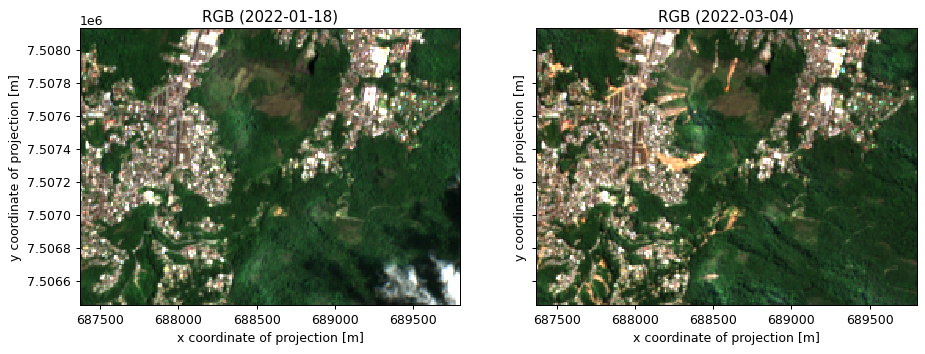

In [15]:
import matplotlib.pyplot as plt

# Agora, é possível visualizar o dataset 

ds = xarray.load_dataset("load-datacube.nc")
# converto o dataset xarrat para (bands, t, x, y) dataArray
data = ds[["B04", "B03", "B02"]].to_array(dim="bands")

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), dpi=90, sharey=True)
data[{"t": 0}].plot.imshow(vmin=0, vmax=2000, ax=axes[0])
axes[0].set_title(f"RGB ({ds['t'][0].values.astype('datetime64[D]')})") # mudança no título
data[{"t": -1}].plot.imshow(vmin=0, vmax=2000, ax=axes[1])
axes[1].set_title(f"RGB ({ds['t'][1].values.astype('datetime64[D]')})");

Com isso, é possível saber qual foi a data das imagens antes e após o deslizamento

In [16]:
timestamp_before = pd.to_datetime(ds.coords["t"].values[0])  # Data de t: 0 (Antes do Deslizamento)
timestamp_after = pd.to_datetime(ds.coords["t"].values[-1])  # Data de t: -1 (Após o Deslizamento)

## Download das imagens RGB

### Como a coleção está trazendo todas as bandas, basta baixar a imagem em formato .tif e selecionar as bandas do RGB no QGIS: 
B04 - red  
B03 - green  
B02 - blue  
Fonte: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

In [19]:
# Imagens RBG
output_path_before = f"{output_dir_RGB}/RGB_before_{timestamp_before.strftime('%Y%m%d')}.tif"
output_path_after = f"{output_dir_RGB}/RGB_after_{timestamp_after.strftime('%Y%m%d')}.tif"

In [20]:
# Faço o download das imagens no formato geotiff
datacube_before.download(output_path_before, format="GTiff")
datacube_after.download(output_path_after, format="GTiff")

## Visualização MSAVI2 (Normalized Difference Vegetation Index)

In [ ]:
def calculate_msavi2(ds):
    nir = ds["B08"]
    red = ds["B04"]
    numerator = 2 * nir + 1
    discriminant = (2 * nir + 1)**2 - 8 * (nir - red)
    msavi2 = (numerator - np.sqrt(discriminant)) / 2
    return msavi2

# aplico a função para calcular o MSAVI2
msavi2_data = calculate_msavi2(ds)

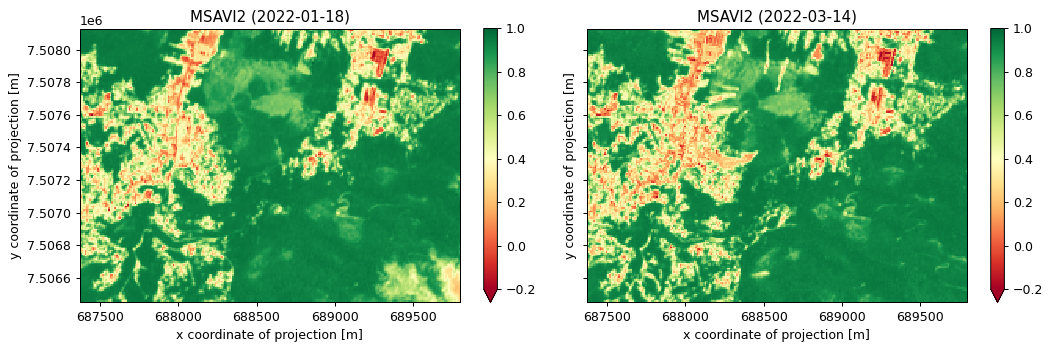

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4), dpi=90, sharey=True)

# personalizando os gráficos
# defini valor máximo 1 e mínimo -1, conforme fórmula do MSAVI2. Inseri o degradê através do colormap "RdY1Gn", que vai do vermelho ao verde

msavi2_data[{"t": 0}].plot.imshow(ax=axes[0],vmin=-0.2, vmax=1, cmap="RdYlGn", add_colorbar=True) 
axes[0].set_title(f"MSAVI2 ({ds['t'][0].values.astype('datetime64[D]')})") # mudança no título

msavi2_data[{"t": -1}].plot.imshow(ax=axes[1], vmin=-0.2, vmax=1, cmap="RdYlGn", add_colorbar=True)
axes[1].set_title(f"MSAVI2 ({ds['t'][-1].values.astype('datetime64[D]')})")

plt.tight_layout()
plt.show()

## Download das imagens MSAVI2 (Normalized Difference Vegetation Index)

In [ ]:
def calc_msavi2(msavi2):
    return msavi2.apply(lambda pixel: (2 * pixel["B08"] + 1 - np.sqrt((2 * pixel["B08"] + 1)**2 - 8 * (pixel["B08"] - pixel["B04"]))) / 2)

# aplico a função para cada período
msavi2_before = calc_msavi2(datacube_before)
msavi2_after  = calc_msavi2(datacube_after)

In [27]:
# aplico a função para cada período
msavi2_before = calc_msavi2(datacube_before)
msavi2_after  = calc_msavi2(datacube_after)

In [30]:
# diretórios de saída para os arquivos TIFF
output_path_before = f"{output_dir_NDVI}/MSAVI2_before_{timestamp_before.strftime('%Y%m%d')}.tif"
output_path_after = f"{output_dir_NDVI}/MSAVI2_after_{timestamp_after.strftime('%Y%m%d')}.tif"

In [ ]:
# Faço o download das imagens no formato geotiff
msavi2_before.download(output_path_before, format="GTiff")
msavi2_after.download(output_path_after, format="GTiff")

## Análise diferencial do MSAVI2

A análise diferencial do MSAVI2 revela a perda de vegetação na área afetada pelo deslizamento. 

Se quisermos verificar o efeito da perda de vegetação, podemos calcular o diferencial MSAVI2 (Δ MSAVI2) subtraindo a matriz MSAVI2 pré-deslizamento da matriz pós-deslizamento.

In [106]:
# Vou carregar os arquivos  GeoTIFF que gerei

msavi2_before = rio.open_rasterio("./sentinel2_10m/MSAVI2/MSAVI2_before_20220118.tif")
msavi2_after = rio.open_rasterio("./sentinel2_10m/MSAVI2/MSAVI2_after_20220314.tif")

In [107]:
# Faço a subtração do posterior com o anterior
msavi2_diff = msavi2_after - msavi2_before

In [108]:
# Gero um geotiff com isso
msavi2_diff.rio.to_raster("./sentinel2_10m/MSAVI2/MSAVI2_difference.tif")

Como o ndvi_diff é um datacube, ele tem uma dimensão band de tamanho 1. Para remover essa dimensão, uso .squeeze()

In [109]:
msavi2_diff = msavi2_diff.squeeze("band", drop=True)

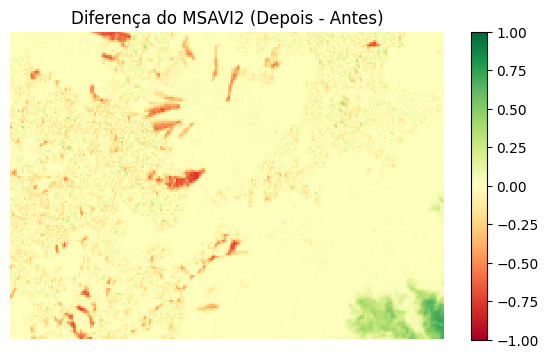

In [ ]:
# Plotagem da diferença
plt.figure(figsize=(7, 4))
msavi2_diff.plot.imshow(
    cmap="RdYlGn",  # colormap para destacar mudanças
    vmin=-1,        # valores mínimos do MSAVI2
    vmax=1,         # valores máximos do MSAVI2
    add_colorbar=True,
)
plt.title("Diferença do MSAVI2 (Depois - Antes)")
plt.axis('off')  # removo eixos
plt.show()

### Agora, eu quero gerar uma visualização em que meu dado só tem diferenças de MSAVI2 acima de -0.3, o que irá indicar as perdas de vegetação por deslizamento

In [111]:
# Gero um binário, em que valores abaixo de -0.1 eu tenho 0, e valores acima disso, eu tenho 1.
msavi2_binary = msavi2_diff.where(msavi2_diff >= -0.3, 0).where(msavi2_diff < -0.3, 1)

In [ ]:
# Download do geotiff
msavi2_binary.rio.to_raster("./sentinel2_10m/MSAVI2/msavi2_binary2.tif")

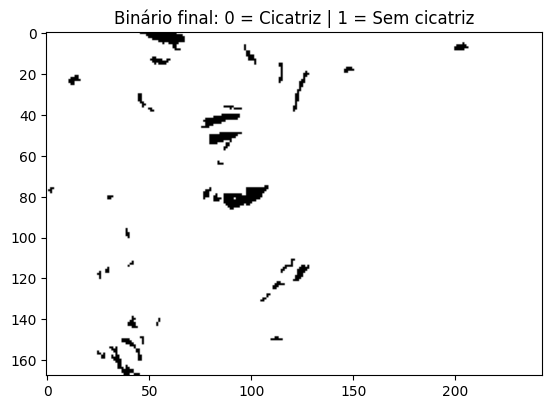

In [ ]:
import numpy as np
import rioxarray as rxr
from scipy import ndimage
import matplotlib.pyplot as plt

# caminhos
diff_path = "./sentinel2_10m/MSAVI2/MSAVI2_difference.tif"
output_path = "./sentinel2_10m/MSAVI2/msavi2_binary.tif"

# abro com rioxarray
msavi2_diff = rxr.open_rasterio(diff_path, masked=True).squeeze()

# gero binário inicial: 1 = possível cicatriz, 0 = não
msavi2_binary = msavi2_diff.copy()
msavi2_binary.data = np.where(msavi2_diff < -0.3, 1, 0).astype(np.uint8)

# Função para remover cicatrizes menores que 4 pixels
def remove_cicatrizes_pequenas(bin_array, min_pixels=4):
    estrutura = ndimage.generate_binary_structure(2, 2)  # conectividade 8
    labeled, num_features = ndimage.label(bin_array == 1, structure=estrutura)
    
    sizes = ndimage.sum(bin_array == 1, labeled, index=range(1, num_features + 1))
    mask = np.zeros_like(bin_array, dtype=np.uint8)

    for i, size in enumerate(sizes):
        if size >= min_pixels:
            mask[labeled == (i + 1)] = 1
    return mask

# aplico filtro
msavi2_cicatriz = remove_cicatrizes_pequenas(msavi2_binary.data)

# Inverto: 0 = cicatriz, 1 = sem cicatriz
msavi2_invertido = 1 - msavi2_cicatriz

# substituo dados mantendo metadados
msavi2_binary.data = msavi2_invertido

# salvo novo raster
msavi2_binary.rio.to_raster(output_path)

# Visualizar
plt.imshow(msavi2_invertido, cmap='gray')
plt.title("Binário final: 0 = Cicatriz | 1 = Sem cicatriz")
plt.show()

### Explicação QGIS

gerando o binário, basta eu classificar no QGIS e visualizar apenas os valores em que ndvi_diff < -0.1

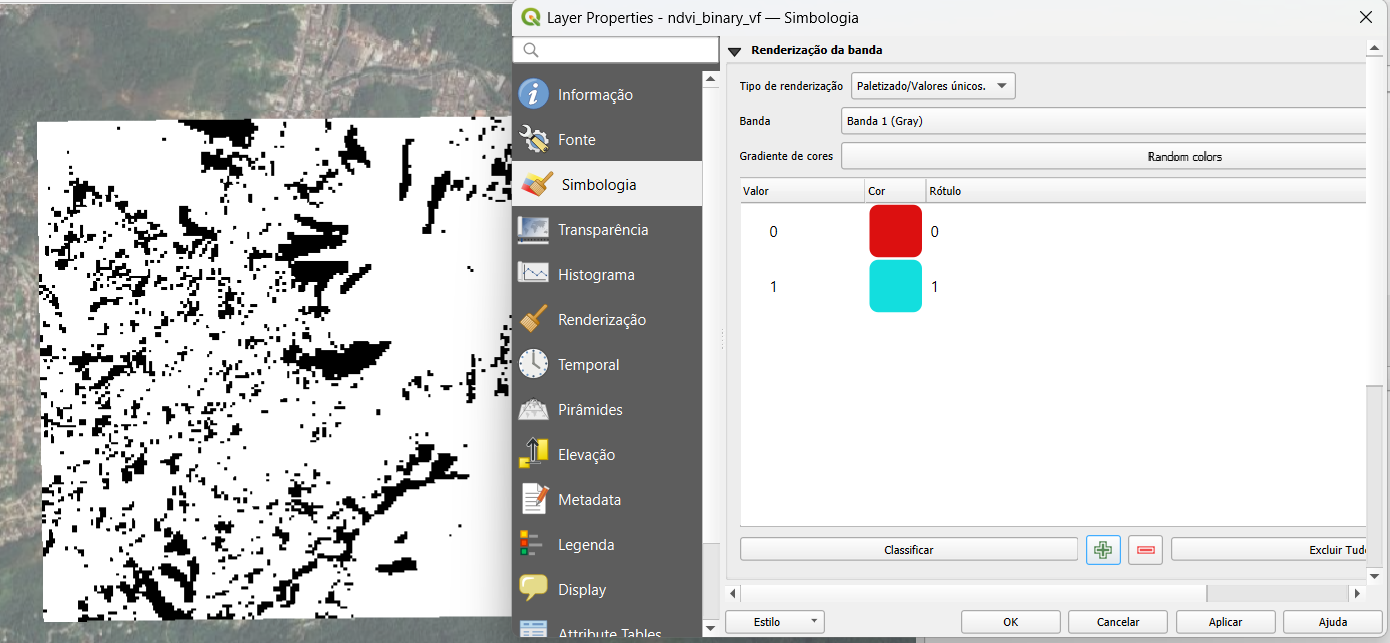

Se eu removo o 1 (cor branca no mapa) e deixo apenas o 0 (cor preta no mapa), consigo visualizar as áreas com vegetação afetada pelo deslizamento

### Cálculo da área afetada

In [ ]:
import rasterio
import numpy as np

# abro o raster binário
path = './sentinel2_10m/MSAVI2/msavi2_binary.tif'

with rasterio.open(path) as src:
    data = src.read(1)
    transform = src.transform
    pixel_area = abs(transform.a * transform.e)  # resolução em m² por pixel

    # conto os pixels com valor 0 (área de deslizamento)
    affected_pixels = np.sum(data == 0)
    affected_area_m2 = affected_pixels * pixel_area
    affected_area_ha = affected_area_m2 / 10_000

    print(f"Área afetada (m²): {affected_area_m2:.2f}")
    print(f"Área afetada (hectares): {affected_area_ha:.2f}")


Área afetada (m²): 86200.00
Área afetada (hectares): 8.62
